In [ ]:
# 필요한 라이브러리 설치
!pip install ultralytics opencv-python-headless

from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
from ultralytics import YOLO
import PIL
import io
import html
import time


YOLO 모델 로딩 중...
모델 로딩 완료!
아래 버튼을 눌러 사진을 캡처하고 객체 탐지를 수행합니다.


<IPython.core.display.Javascript object>

객체 탐지 중...

0: 480x640 1 person, 1 dog, 1 cell phone, 161.7ms
Speed: 3.9ms preprocess, 161.7ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

탐지된 객체:
  - cell phone: 0.93
  - person: 0.85
  - dog: 0.36



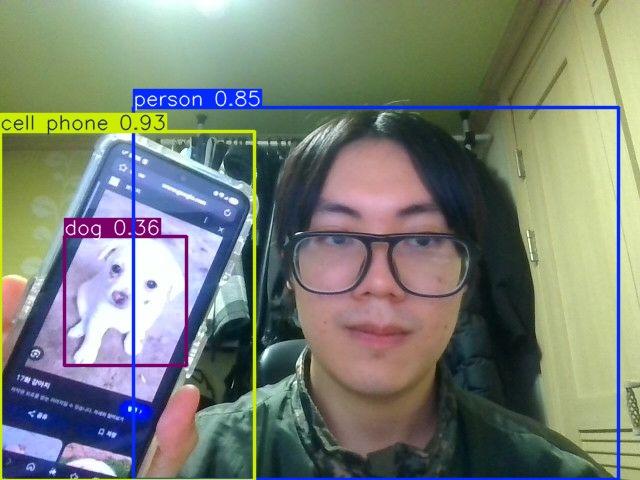

In [ ]:

# YOLO 모델 로드 (YOLOv8n - 가장 빠른 모델)
print("YOLO 모델 로딩 중...")
model = YOLO('yolov8n.pt')  # yolov8s.pt, yolov8m.pt 등으로 변경 가능
print("모델 로딩 완료!")

# 웹캠에서 이미지 캡처하는 JavaScript 함수
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            const stop = document.createElement('button');
            capture.textContent = '📸 캡처';
            stop.textContent = '⏹️ 중지';
            capture.style.margin = '10px';
            stop.style.margin = '10px';
            div.appendChild(capture);
            div.appendChild(stop);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            document.body.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // 캡처 버튼을 기다립니다
            await new Promise((resolve) => {
                capture.onclick = () => resolve();
                stop.onclick = () => {
                    stream.getTracks().forEach(track => track.stop());
                    div.remove();
                    video.remove();
                    throw new Error('중지됨');
                };
            });

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            div.remove();
            video.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    return data

# 연속 캡처를 위한 JavaScript 함수
def start_video_stream():
    js = Javascript('''
        async function startStream() {
            const div = document.createElement('div');
            div.id = 'stream-controls';
            const video = document.createElement('video');
            video.id = 'stream-video';
            video.style.display = 'block';
            video.autoplay = true;

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(video);
            video.srcObject = stream;

            return "스트림 시작됨";
        }
        ''')
    display(js)
    return eval_js('startStream()')

def capture_frame():
    js = Javascript('''
        function captureFrame() {
            const video = document.getElementById('stream-video');
            if (!video) return null;

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            return canvas.toDataURL('image/jpeg', 0.8);
        }
        ''')
    display(js)
    return eval_js('captureFrame()')

def stop_video_stream():
    js = Javascript('''
        function stopStream() {
            const video = document.getElementById('stream-video');
            if (video && video.srcObject) {
                video.srcObject.getTracks().forEach(track => track.stop());
                video.remove();
            }
            return "스트림 중지됨";
        }
        ''')
    display(js)
    return eval_js('stopStream()')

# Base64 이미지를 OpenCV 형식으로 변환
def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(jpg_as_np, flags=1)
    return img

# OpenCV 이미지를 Base64로 변환
def array_to_data_url(img):
    _, buffer = cv2.imencode('.jpg', img)
    jpg_as_text = b64encode(buffer).decode()
    return f'data:image/jpeg;base64,{jpg_as_text}'

# 이미지 표시 함수
def show_image(img_data_url):
    display(HTML(f'<img src="{img_data_url}" style="max-width:640px">'))

print("아래 버튼을 눌러 사진을 캡처하고 객체 탐지를 수행합니다.")

try:
    # 사진 캡처
    image_data = take_photo()

    # 이미지 변환
    image = js_to_image(image_data)

    # YOLO 추론
    print("객체 탐지 중...")
    results = model(image)

    # 결과를 이미지에 그리기
    annotated_frame = results[0].plot()

    # 결과 표시
    print("\n탐지된 객체:")
    for r in results:
        for box in r.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            label = model.names[cls]
            print(f"  - {label}: {conf:.2f}")

    # 이미지 표시
    from IPython.display import HTML
    annotated_data_url = array_to_data_url(annotated_frame)
    display(HTML(f'<img src="{annotated_data_url}" style="max-width:800px">'))

except Exception as e:
    print(f"오류 발생: {e}")
